## Amplitude Rabi

In [23]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
)
from laboneq.analysis.fitting import oscillatory

print(laboneq.__version__)

2.54.0


In [24]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = True
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.24 03:18:58.748] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is /Users/yizheng/Downloads/Qubit_measurement/laboneq_output/log
[2025.08.24 03:18:58.751] INFO    VERSION: laboneq 2.54.0


[2025.08.24 03:18:58.752] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.24 03:18:58.755] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.1.17 at 127.0.0.1:8004
[2025.08.24 03:18:58.757] INFO    Configuring the device setup
[2025.08.24 03:18:58.760] INFO    The device setup is configured


In [25]:
# range of pulse amplitude scan


def create_rabi_amp_sweep(amp_num, uid="rabi_amp"):
    amp_min = 0
    amp_max = 1
    return LinearSweepParameter(uid=uid, start=amp_min, stop=amp_max, count=amp_num)


# define number of averages
# used for 2^num_averages, maximum: num_averages = 17
num_averages = 4


# pulse parameters and definitions
envelope_duration = 2.0e-6
sigma = 0.2
flat_duration = 1.0e-6


def create_readout_pulse(
    qubit, length=envelope_duration, amplitude=0.9, width=flat_duration, sigma=sigma
):
    readout_pulse = pulse_library.gaussian_square(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude,
        width=width,
        sigma=sigma,
    )
    return readout_pulse


def create_rabi_drive_pulse(qubit, length=1e-6, amplitude=0.9):
    return pulse_library.gaussian(
        uid=f"gaussian_drive_q{qubit}", length=length, amplitude=amplitude
    )

In [26]:
# function that returns an amplitude Rabi experiment


def amplitude_rabi(drive_pulse, readout_pulse, amplitude_sweep):
    exp_rabi = Experiment(
        uid="Amplitude Rabi",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_rabi.acquire_loop_rt(
        uid="rabi_shots",
        count=num_averages,
        averaging_mode=AveragingMode.CYCLIC,
        acquisition_type=AcquisitionType.INTEGRATION,
    ):
        # inner loop - real time sweep of Rabi ampitudes
        with exp_rabi.sweep(uid="rabi_sweep", parameter=amplitude_sweep):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_rabi.section(
                uid="qubit_excitation", alignment=SectionAlignment.RIGHT
            ):
                exp_rabi.play(
                    signal="drive", pulse=drive_pulse, amplitude=amplitude_sweep
                )
            # readout pulse and data acquisition
            with exp_rabi.section(uid="readout_section", play_after="qubit_excitation"):
                # play readout pulse on measure line
                exp_rabi.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_rabi.acquire(
                    signal="acquire",
                    handle="amp_rabi",
                    kernel=readout_pulse,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_rabi.section(uid="reserve", length=1e-6):
                exp_rabi.reserve(signal="measure")
    return exp_rabi

In [27]:
# define pulses and create experiment
readout_pulse = create_readout_pulse("q0")
drive_pulse = create_rabi_drive_pulse("q0")
exp_rabi = amplitude_rabi(drive_pulse, readout_pulse, create_rabi_amp_sweep(amp_num=61))


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map


# run the experiment on qubit 0
exp_rabi.set_signal_map(signal_map_default("q0"))

In [28]:
# compile the experiment on the open instrument session
compiled_rabi = session.compile(exp_rabi)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Rabi", compiled_rabi)

[2025.08.24 03:19:05.871] INFO    Starting LabOne Q Compiler run...
[2025.08.24 03:19:05.896] INFO    Schedule completed. [0.020 s]
[2025.08.24 03:19:05.919] INFO    Code generation completed for all AWGs. [0.022 s]
[2025.08.24 03:19:05.919] INFO    Completed compilation step 1 of 1. [0.044 s]
[2025.08.24 03:19:05.923] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.24 03:19:05.923] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.24 03:19:05.924] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.24 03:19:05.924] INFO      device_shfqc        0         10            0           1      8000  
[2025.08.24 03:19:05.925] INFO      device_shfqc_sg     1        134           62           2      8000  
[2025.08.24 03:19:05.925] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.24 03:19:05.926] INFO      TOTAL                        144 

/Users/yizheng/Downloads/Qubit_measurement/Pulse_Sheets/Rabi_2025-08-24-03-19-05.html

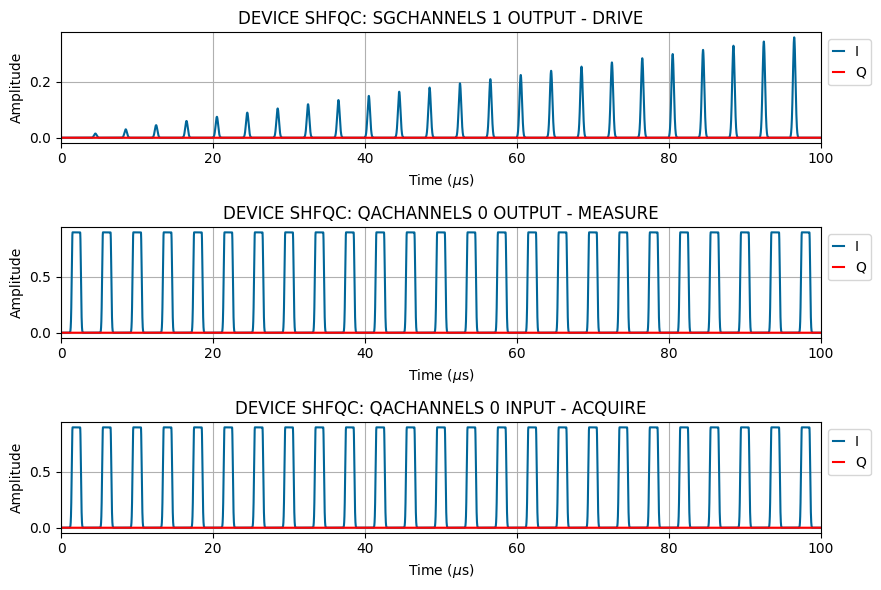

In [29]:
plot_simulation(compiled_rabi, start_time=0, length=100e-6)

In [30]:
# run the compiled experiemnt
rabi_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)
save(rabi_results,f"Results/{timestamp}_rabi_results.json")
print(f"File saved as Results/{timestamp}_rabi_results.json")

[2025.08.24 03:19:08.906] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.24 03:19:08.909] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.1.17 at 127.0.0.1:8004
[2025.08.24 03:19:08.911] INFO    Configuring the device setup
[2025.08.24 03:19:08.913] INFO    The device setup is configured
[2025.08.24 03:19:08.917] CRITICAL SHFQC/SG:dev12296: Local oscillator for channel 1 is required, but is not provided.


[2025.08.24 03:19:08.917] CRITICAL SHFQC/SG:dev12296: Local oscillator for channel 1 is required, but is not provided.


LabOneQControllerException: SHFQC/SG:dev12296: Local oscillator for channel 1 is required, but is not provided.

In [31]:
plot_results(rabi_results)

NameError: name 'rabi_results' is not defined

In [32]:
# get measurement data returned by the instruments
rabi_res = rabi_results.get_data("amp_rabi")

# define amplitude axis from qubit parameters
rabi_amp = rabi_results.get_axis("amp_rabi")[0]

if use_emulation:
    # create some dummy data if running in emulation mode
    rabi_res = oscillatory(rabi_amp, 10, 0, 1, 1.2) + 0.2 * np.random.rand(
        len(rabi_amp)
    )

# plot measurement data
fig = plt.figure()
plt.plot(rabi_amp, rabi_res, ".k")
plt.ylabel("A (a.u.)")
plt.xlabel("amplitude (a.u.)")

# increase number of plot points for smooth plotting of fit results
amp_plot = np.linspace(rabi_amp[0], rabi_amp[-1], 5 * len(rabi_amp))

# fit measurement results - assume sinusoidal oscillation with drive amplitude
popt, pcov = oscillatory.fit(rabi_amp, rabi_res, 10, 0, 1, 1.2, plot=False)
print(f"Fitted parameters: {popt}")

# plot fit results together with measurement data
plt.plot(amp_plot, oscillatory(amp_plot, *popt), "-r")
plt.show()

NameError: name 'rabi_results' is not defined

## Length Rabi

In [ ]:
# set up sweep parameter - drive pulse length
start = 30e-9
stop = 200e-9
count = 11
length_sweep = LinearSweepParameter(uid="length", start=start, stop=stop, count=count)

# number of averages
average_exponent = 1  # used for 2^n averages, n=average_exponent, maximum: n = 17

# Create Experiment
exp = Experiment(
    uid="Length Rabi",
    signals=[
        ExperimentSignal("drive"),
        ExperimentSignal("measure"),
        ExperimentSignal("acquire"),
    ],
)
## experimental pulse sequence
# outer loop - real-time, cyclic averaging in standard integration mode
with exp.acquire_loop_rt(
    uid="shots",
    count=pow(2, average_exponent),
    averaging_mode=AveragingMode.CYCLIC,
    acquisition_type=AcquisitionType.INTEGRATION,
    repetition_mode=RepetitionMode.AUTO,  # the compiler determines the optimal shot repetition rate
):
    # inner loop - real-time sweep of qubit drive pulse amplitude
    with exp.sweep(
        uid="sweep", parameter=length_sweep, alignment=SectionAlignment.RIGHT
    ):
        # qubit excitation - pulse length will be swept
        with exp.section(uid="qubit_excitation", alignment=SectionAlignment.RIGHT):
            exp.play(signal="drive", pulse=x90, length=length_sweep)
        # qubit readout pulse and data acquisition
        with exp.section(uid="qubit_readout", play_after="qubit_excitation"):
            # play readout pulse
            exp.play(signal="measure", pulse=readout_pulse)
            # signal data acquisition
            exp.acquire(
                signal="acquire",
                handle="ac_0",
                kernel=readout_weighting_function,
            )
        # relax time after readout - for signal processing and qubit relaxation to ground state
        with exp.section(uid="relax", length=1e-6):
            exp.reserve(signal="measure")

In [ ]:
# set signal map to qubit 0
exp.set_signal_map(map_qubit(q0))

# run experiment on qubit 0
my_results = session.run(exp)

In [ ]:
# Plot simulated output signals
plot_simulation(session.compiled_experiment, start_time=0, length=10e-6)

In [ ]:
# plot measurement results
plot_result_2d(my_results, "ac_0")

In [ ]:
# use pulse sheet viewer to display the pulse sequence - only recommended for small number of averages and sweep steps to avoid performance issues
show_pulse_sheet("Length Rabi", session.compiled_experiment)

In [ ]:
# set signal map to qubit 1
exp.set_signal_map(map_qubit(q1))

# run experiment on qubit 1
my_results = session.run(exp)